In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

In [11]:
df = pd.read_csv("/content/custom_multi_year_diabetes_dataset.csv")

df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year
0,69.0,Male,26.7,122.0,72.0,13.9,2,2013-2014
1,54.0,Male,28.6,156.0,62.0,9.1,2,2013-2014
2,72.0,Male,28.9,140.0,90.0,8.9,2,2013-2014
3,73.0,Female,19.7,136.0,86.0,4.9,0,2013-2014
4,56.0,Male,41.7,160.0,84.0,5.5,0,2013-2014


In [13]:
df.shape

(20111, 8)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20111 entries, 0 to 20110
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              20111 non-null  float64
 1   Gender           20111 non-null  object 
 2   BMI              19834 non-null  float64
 3   Systolic_BP      18409 non-null  float64
 4   Diastolic_BP     18409 non-null  float64
 5   HbA1c_Level      19001 non-null  float64
 6   Diabetes_Status  20111 non-null  int64  
 7   Source_Year      20111 non-null  object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.2+ MB


In [14]:
df.describe()

,Age,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status
count,20111.000000,19834.000000,18409.000000,1.840900e+04,19001.000000,20111.000000
mean,43.452439,28.527619,122.089739,6.846542e+01,5.717578,0.260355
std,20.902683,7.358994,18.632175,1.376197e+01,1.050946,0.654889
min,12.000000,13.200000,66.000000,5.397605e-79,3.500000,0.000000
25%,24.000000,23.325000,108.000000,6.000000e+01,5.200000,0.000000
50%,43.000000,27.400000,118.000000,6.800000e+01,5.500000,0.000000
75%,61.000000,32.300000,132.000000,7.600000e+01,5.800000,0.000000
max,80.000000,86.200000,236.000000,1.360000e+02,17.500000,2.000000


In [53]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'HbA1c_Level',
       'Diabetes_Status', 'Source_Year_2015-2016', 'Source_Year_2017-2018'],
      dtype='object')

In [54]:
df.dtypes

,0
Age,float64
Gender,int64
BMI,float64
Systolic_BP,float64
Diastolic_BP,float64
HbA1c_Level,float64
Diabetes_Status,int64
Source_Year_2015-2016,bool
Source_Year_2017-2018,bool


In [55]:
df.sample(5)

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year_2015-2016,Source_Year_2017-2018
16218,16.0,1,19.9,96.0,62.0,5.5,0,False,True
858,16.0,1,20.3,106.0,70.0,5.5,0,False,False
18923,17.0,1,24.4,124.0,64.0,5.2,0,False,True
3000,65.0,1,25.1,120.0,72.0,12.5,2,False,False
12926,55.0,1,26.6,124.0,80.0,5.5,0,True,False


In [56]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Systolic_BP,0
Diastolic_BP,0
HbA1c_Level,0
Diabetes_Status,0
Source_Year_2015-2016,0
Source_Year_2017-2018,0


In [15]:
(df.isnull().sum()/len(df))*100

,0
Age,0.000000
Gender,0.000000
BMI,1.377356
Systolic_BP,8.463030
Diastolic_BP,8.463030
HbA1c_Level,5.519368
Diabetes_Status,0.000000
Source_Year,0.000000


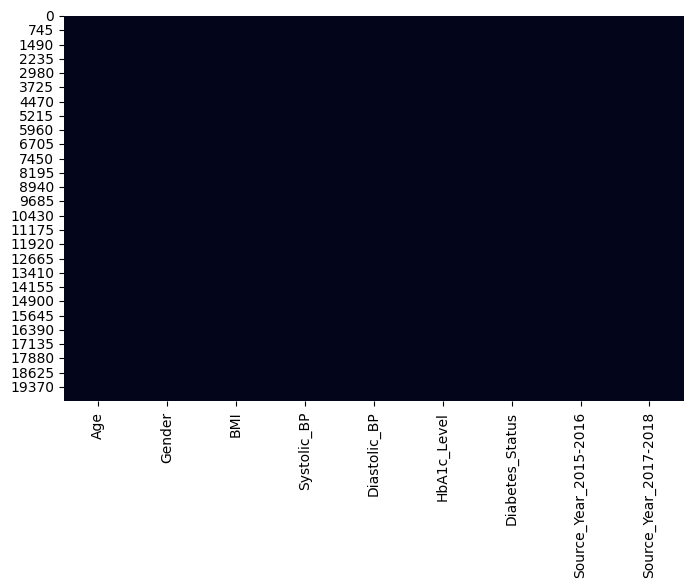

In [57]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df = df.drop_duplicates()

In [60]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*30)

Age
[69. 54. 72. 73. 56. 61. 65. 26. 76. 33. 16. 32. 18. 12. 38. 50. 23. 13.
 28. 14. 35. 29. 58. 57. 20. 37. 75. 43. 60. 55. 62. 36. 80. 31. 63. 71.
 67. 64. 46. 44. 19. 70. 59. 25. 39. 24. 30. 49. 45. 51. 77. 78. 66. 47.
 48. 53. 15. 17. 42. 21. 68. 52. 34. 40. 27. 41. 22. 79. 74.]
------------------------------
Gender
[1 0]
------------------------------
BMI
[26.7 28.6 28.9 19.7 41.7 35.7 26.5 22.  20.3 34.4 22.8 23.2 35.6 15.5
 35.9 23.6 18.6 25.3 30.1 38.7 26.2 31.  24.7 31.2 38.3 32.  31.8 17.8
 36.8 20.9 34.9 24.2 21.1 26.9 38.9 39.1 21.6 26.  24.  32.7 27.3 24.6
 26.3 28.3 36.5 20.4 31.7 30.5 24.8 30.3 22.1 19.3 37.8 25.8 29.2 27.7
 36.4 36.2 28.  30.4 46.1 21.  23.4 33.  35.1 29.1 32.3 34.8 21.3 27.
 21.5 37.6 33.7 18.  33.6 21.4 18.9 23.8 35.2 26.8 22.5 22.7 46.2 26.1
 30.8 32.2 25.9 30.9 26.4 34.6 32.5 40.9 33.4 19.2 25.1 21.2 44.5 27.5
 19.1 25.6 37.5 17.2 39.7 22.2 36.  19.  28.5 40.3 20.6 52.3 18.1 24.1
 30.2 24.9 29.7 28.2 29.9 64.7 54.2 23.  49.9 27.8 33.5 25.  18.2 21.

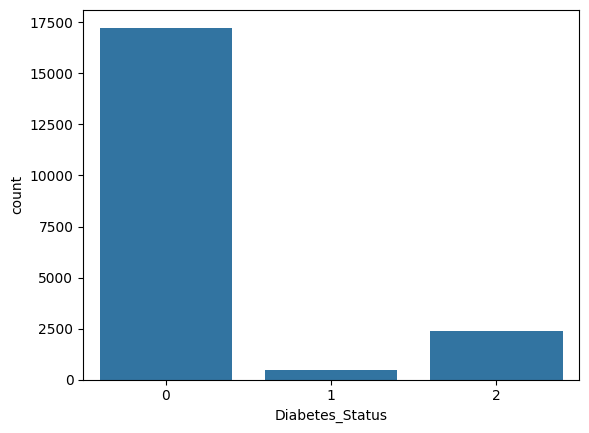

In [61]:
sns.countplot(x="Diabetes_Status", data=df)
plt.show()

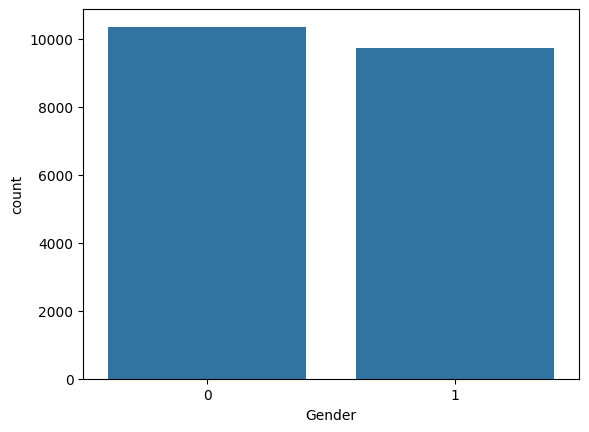

In [62]:
sns.countplot(x="Gender", data=df)
plt.show()

In [63]:
plt.figure(figsize=(8,4))
sns.countplot(x="Source_Year", data=df)
plt.xticks(rotation=45)
plt.show()

ValueError: Could not interpret value `Source_Year` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x400 with 0 Axes>

In [65]:
num_cols = df.select_dtypes(include=np.number).columns

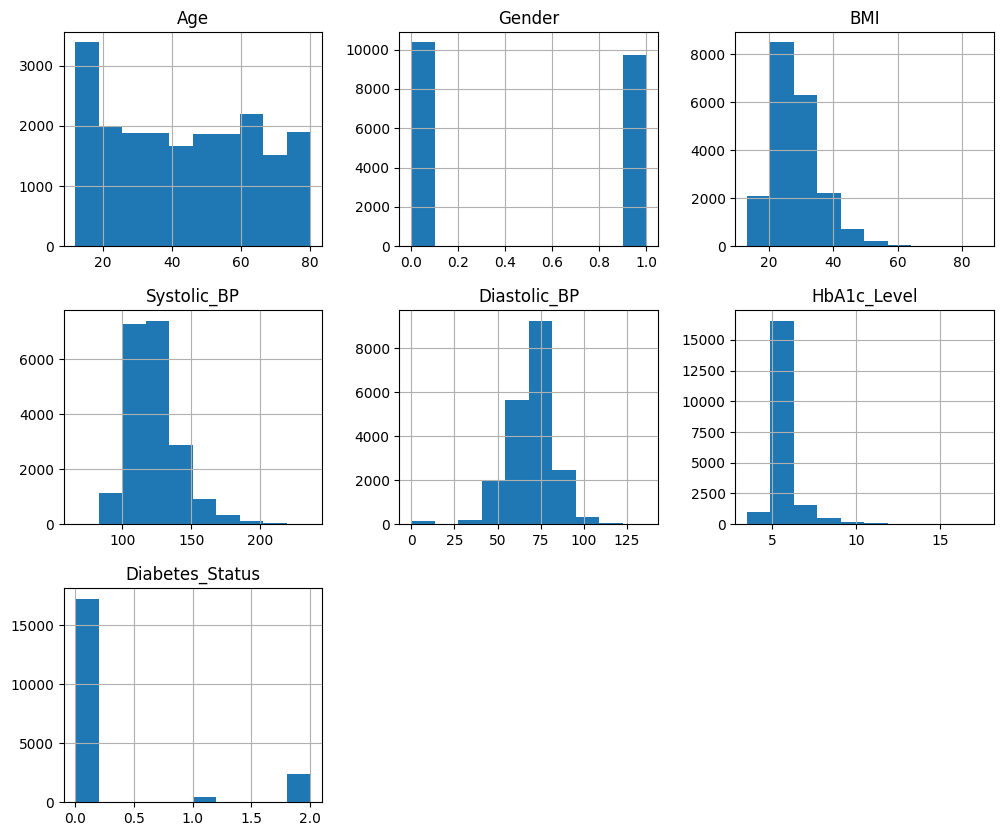

In [72]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12,10))
plt.show()

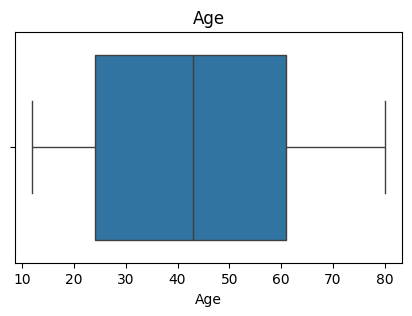

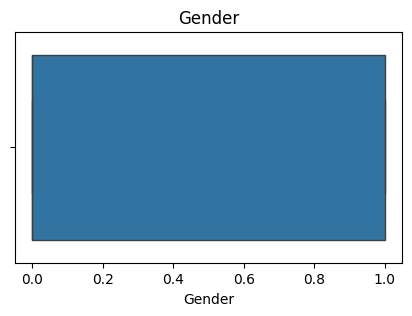

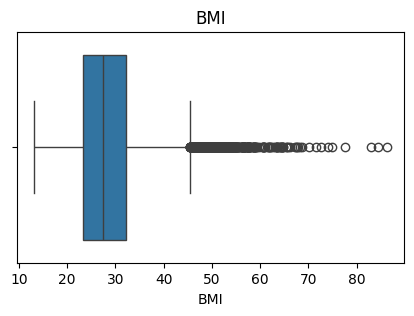

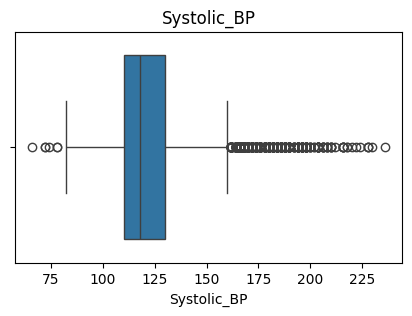

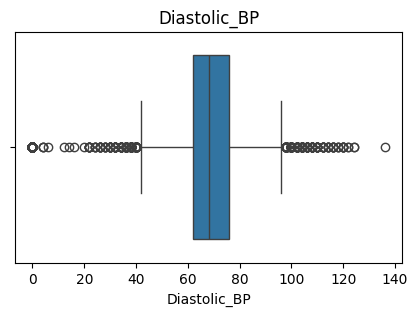

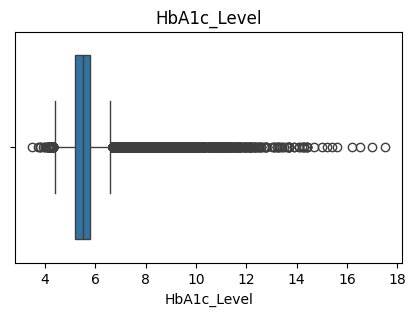

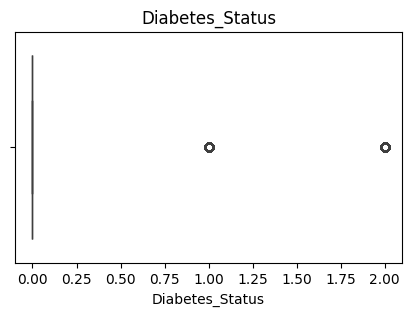

In [66]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

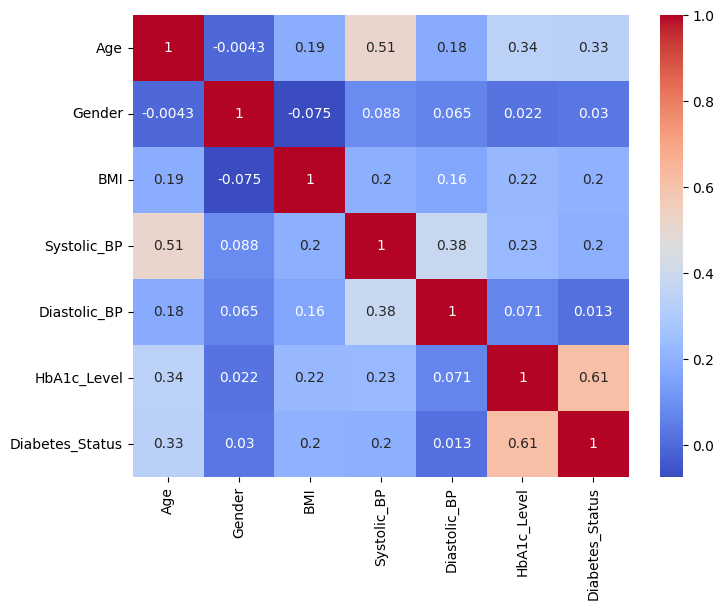

In [67]:
plt.figure(figsize=(8,6))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.show()


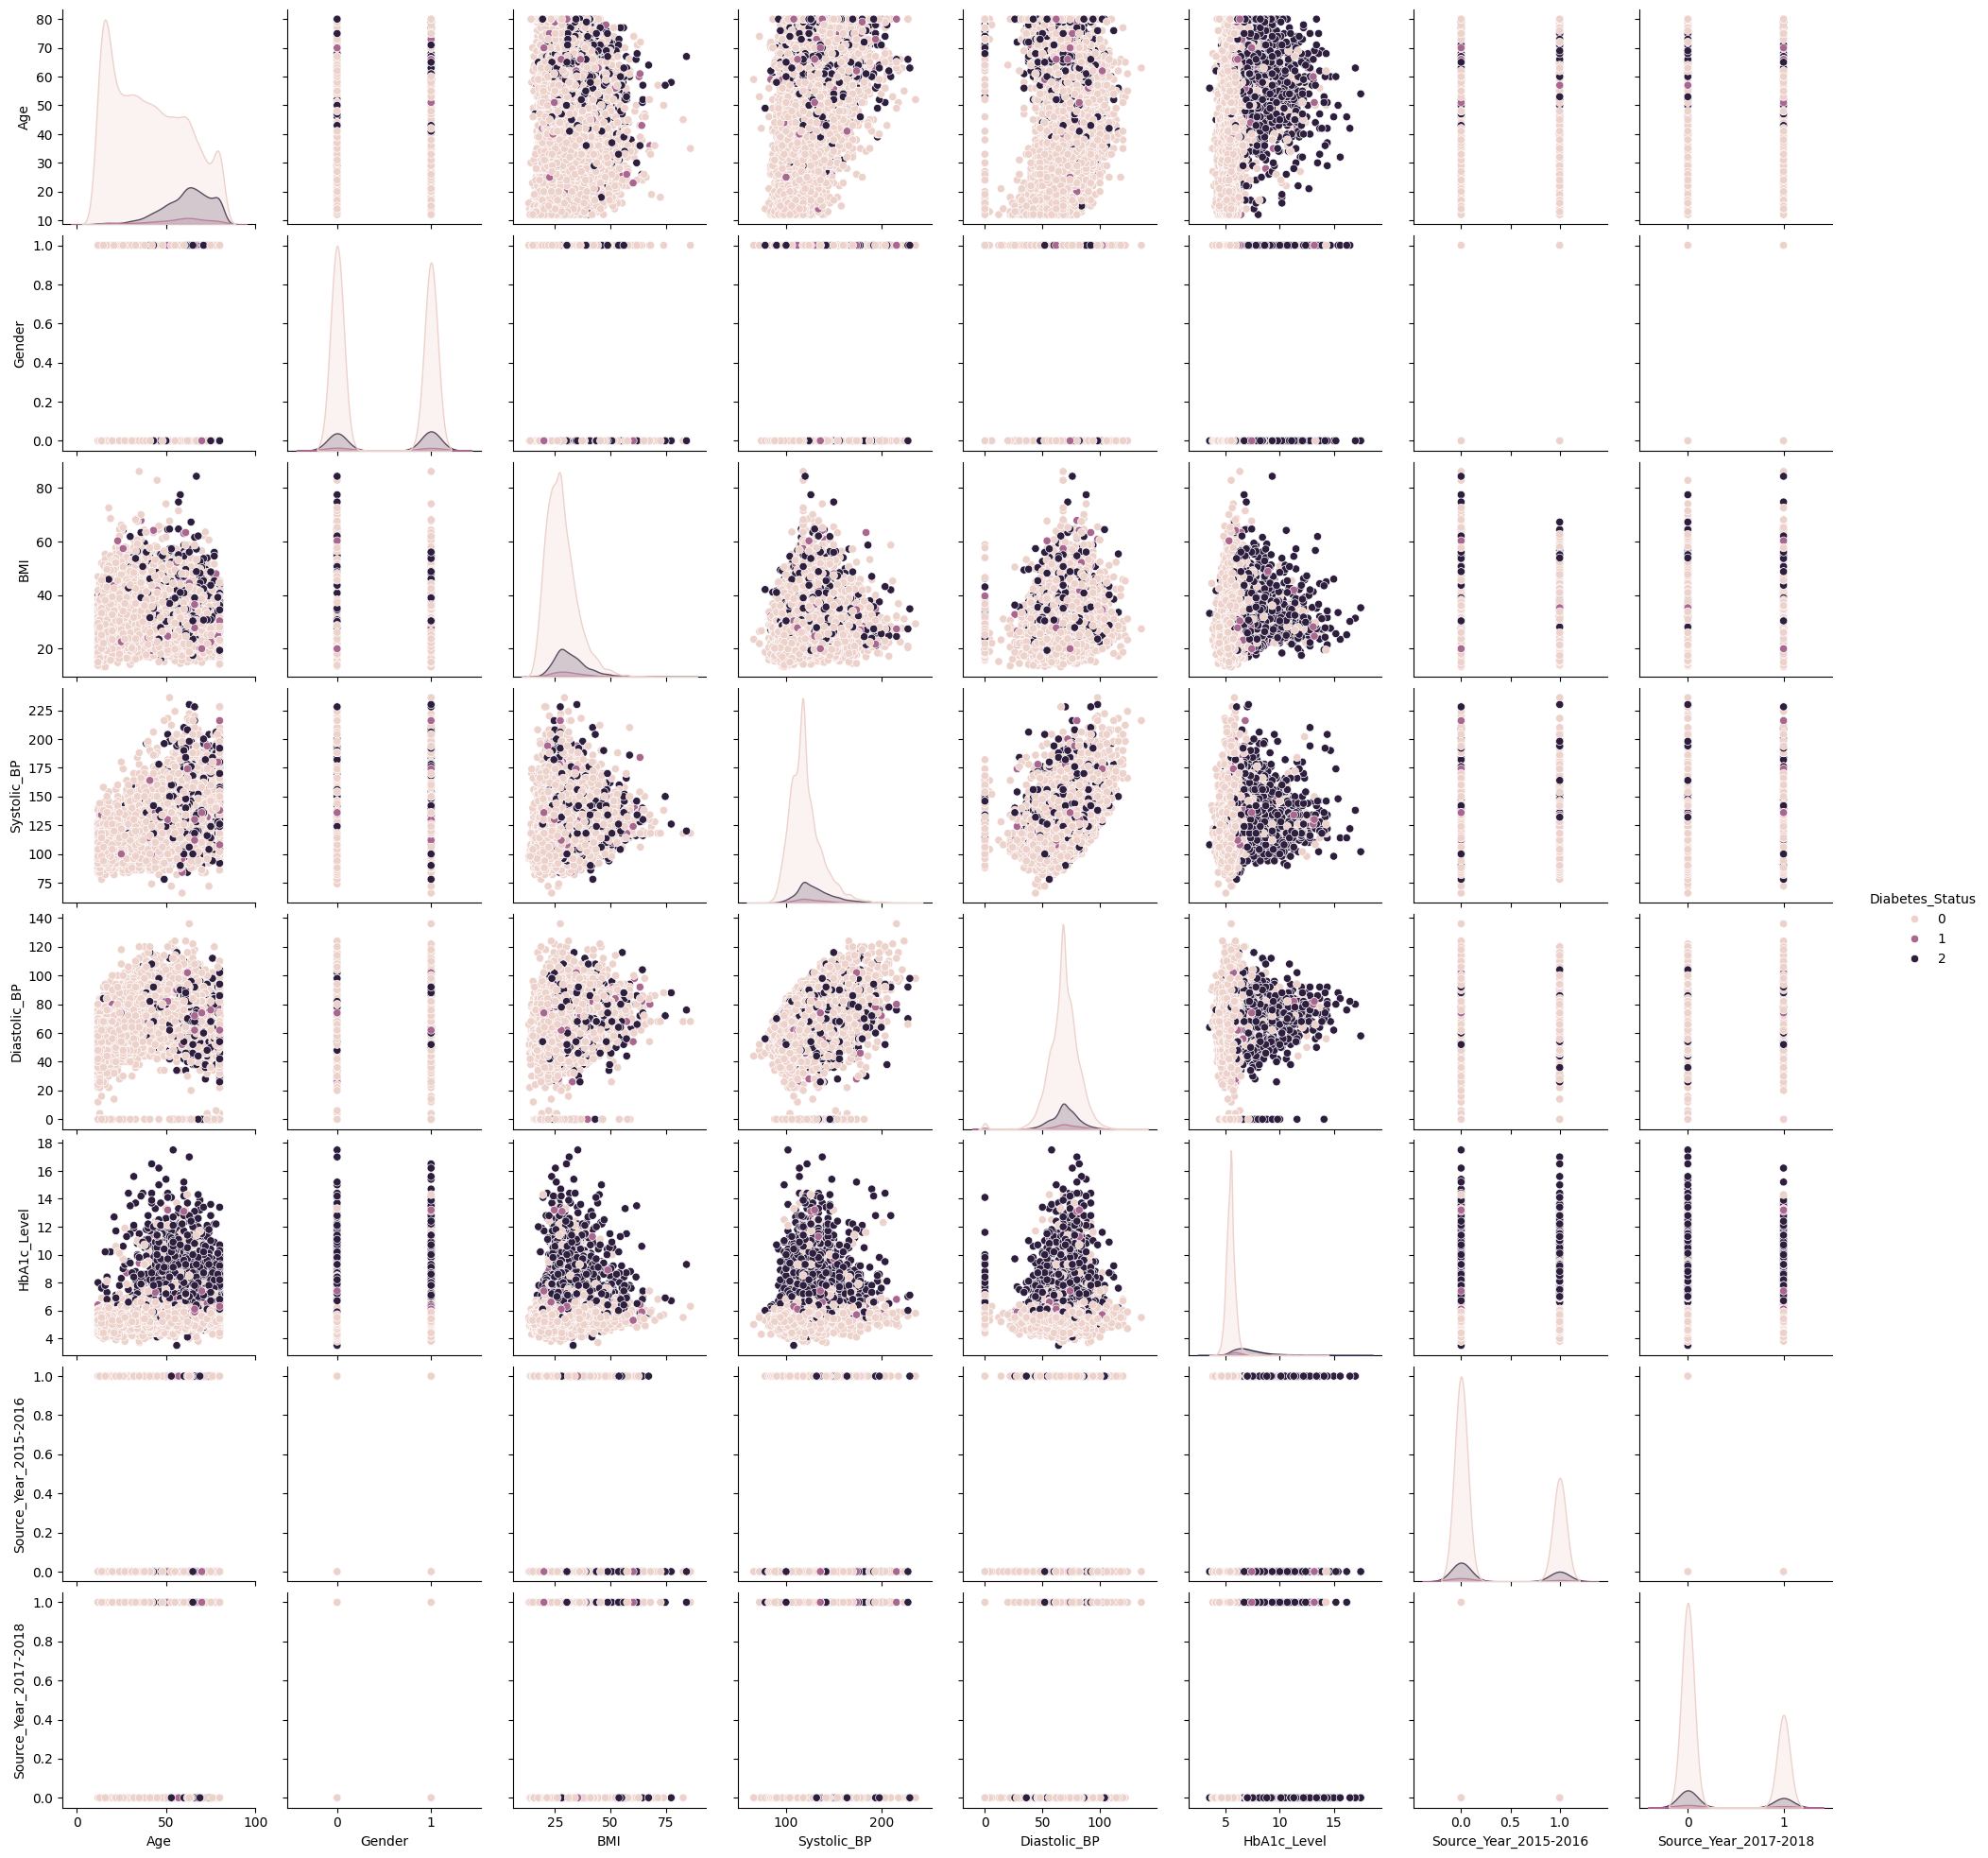

In [68]:
sns.pairplot(df,
             hue="Diabetes_Status")

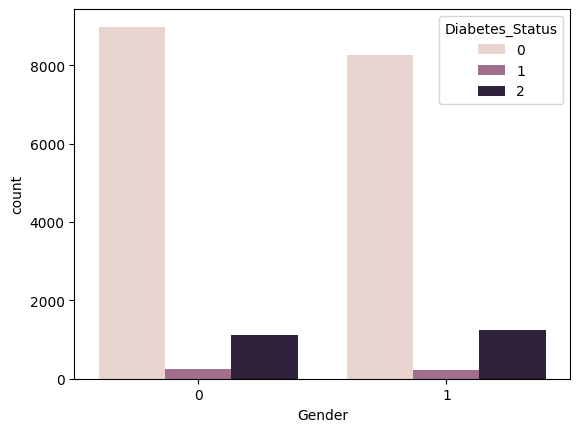

In [69]:
sns.countplot(x="Gender",
              hue="Diabetes_Status",
              data=df)
plt.show()

<Axes: xlabel='Diabetes_Status', ylabel='Age'>

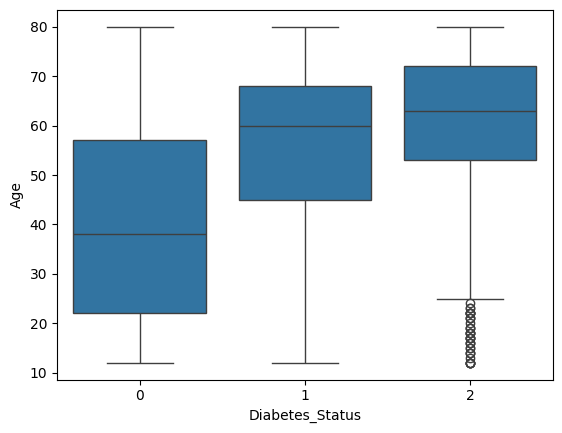

In [70]:
sns.boxplot(x="Diabetes_Status",
            y="Age",
            data=df)

<Axes: xlabel='Diabetes_Status', ylabel='BMI'>

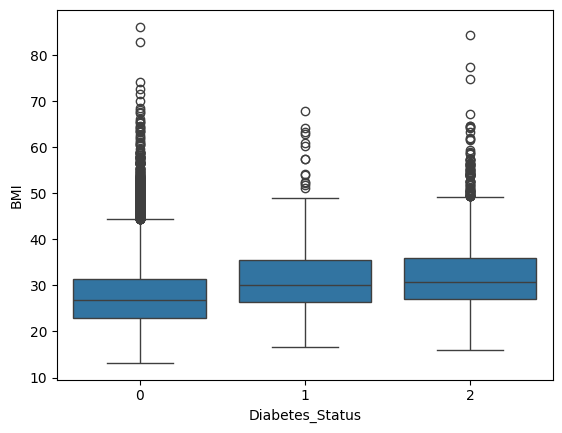

In [71]:
sns.boxplot(x="Diabetes_Status",
            y="BMI",
            data=df)

<Axes: xlabel='Diabetes_Status', ylabel='HbA1c_Level'>

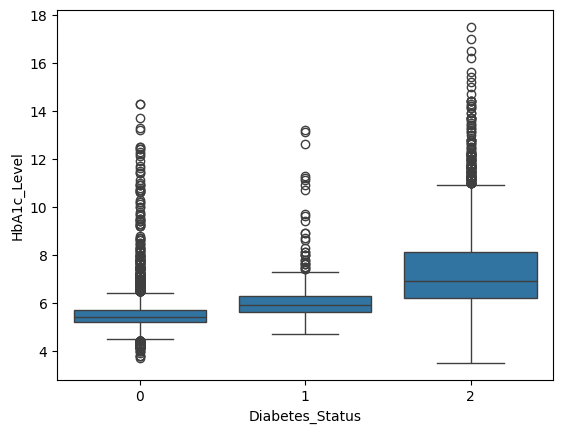

In [73]:
sns.boxplot(x="Diabetes_Status",
            y="HbA1c_Level",
            data=df)


<Axes: xlabel='Diabetes_Status', ylabel='Systolic_BP'>

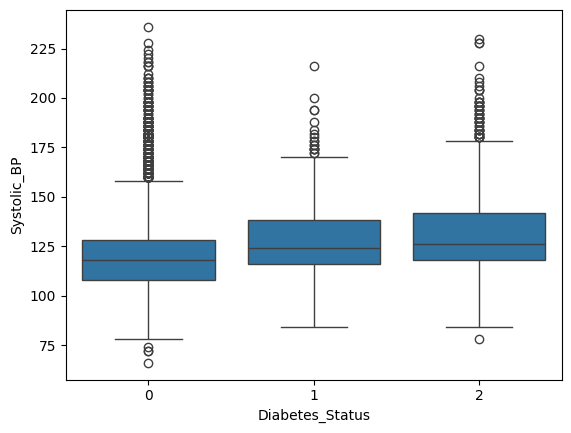

In [74]:
sns.boxplot(x="Diabetes_Status",
            y="Systolic_BP",
            data=df)

In [21]:
df["BMI"].fillna(df["BMI"].median(), inplace=True)

df["Systolic_BP"].fillna(df["Systolic_BP"].median(), inplace=True)

df["Diastolic_BP"].fillna(df["Diastolic_BP"].median(), inplace=True)

df["HbA1c_Level"].fillna(df["HbA1c_Level"].median(), inplace=True)

In [20]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [22]:
# The 'Source_Year' column has already been one-hot encoded and removed
# from the DataFrame in a previous step. This cell is redundant.

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
BMI,0
Systolic_BP,0
Diastolic_BP,0
HbA1c_Level,0
Diabetes_Status,0
Source_Year_2015-2016,0
Source_Year_2017-2018,0


In [17]:
X = df.drop("Diabetes_Status", axis=1)

y = df["Diabetes_Status"]

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [16]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the original dataset
df = pd.read_csv("/content/custom_multi_year_diabetes_dataset.csv")

# Re-apply preprocessing steps
# Drop duplicates
df = df.drop_duplicates()

# Fill missing numerical values with the median
df["BMI"].fillna(df["BMI"].median(), inplace=True)
df["Systolic_BP"].fillna(df["Systolic_BP"].median(), inplace=True)
df["Diastolic_BP"].fillna(df["Diastolic_BP"].median(), inplace=True)
df["HbA1c_Level"].fillna(df["HbA1c_Level"].median(), inplace=True)

# Encode categorical features
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(df, columns=["Source_Year"], drop_first=True)

df.to_csv("processed_diabetes_dataset.csv", index=False)
print("CSV file saved successfully!")

CSV file saved successfully!


In [3]:
import os

os.listdir()

['.config', 'sample_data']

In [2]:
import pandas as pd
import numpy as np

# Model Selection
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load the original dataset
df = pd.read_csv("/content/custom_multi_year_diabetes_dataset.csv")

# Re-apply preprocessing steps
# Drop duplicates
df = df.drop_duplicates()

# Fill missing numerical values with the median
df["BMI"].fillna(df["BMI"].median(), inplace=True)
df["Systolic_BP"].fillna(df["Systolic_BP"].median(), inplace=True)
df["Diastolic_BP"].fillna(df["Diastolic_BP"].median(), inplace=True)
df["HbA1c_Level"].fillna(df["HbA1c_Level"].median(), inplace=True)

# Encode categorical features
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])

df = pd.get_dummies(df, columns=["Source_Year"], drop_first=True)

# Define X and y
X = df.drop("Diabetes_Status", axis=1)
y = df["Diabetes_Status"]

In [25]:
df = pd.read_csv("processed_diabetes_dataset.csv")

In [26]:
df.head()

,Age,Gender,BMI,Systolic_BP,Diastolic_BP,HbA1c_Level,Diabetes_Status,Source_Year_2015-2016,Source_Year_2017-2018
0,69.0,1,26.7,122.0,72.0,13.9,2,False,False
1,54.0,1,28.6,156.0,62.0,9.1,2,False,False
2,72.0,1,28.9,140.0,90.0,8.9,2,False,False
3,73.0,0,19.7,136.0,86.0,4.9,0,False,False
4,56.0,1,41.7,160.0,84.0,5.5,0,False,False


In [27]:
print(df.shape)

(20107, 9)


In [28]:
X = df.drop("Diabetes_Status", axis=1)

y = df["Diabetes_Status"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (16085, 8)
Testing Samples  : (4022, 8)


In [31]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
lr_pred = lr.predict(X_test)

In [33]:
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average="weighted"))
print("Recall   :", recall_score(y_test, lr_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, lr_pred, average="weighted"))

Accuracy : 0.9085032322227747
Precision: 0.8822490272419007
Recall   : 0.9085032322227747
F1 Score : 0.8905374796568262


In [34]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95      3450
           1       0.00      0.00      0.00        97
           2       0.82      0.53      0.64       475

    accuracy                           0.91      4022
   macro avg       0.58      0.50      0.53      4022
weighted avg       0.88      0.91      0.89      4022



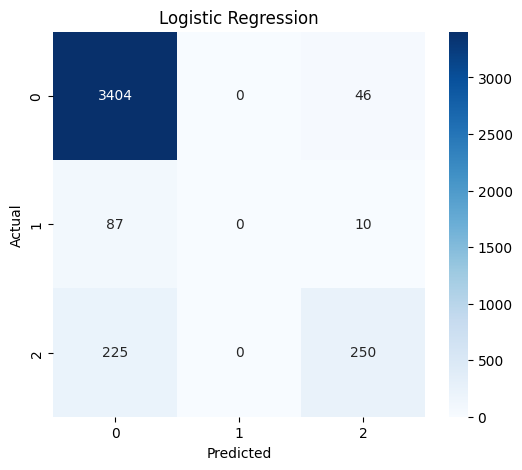

In [35]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")

plt.show()

In [36]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [37]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.8446046742913973


In [38]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [39]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy : 0.9144704127299851
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      3450
           1       0.00      0.00      0.00        97
           2       0.78      0.63      0.69       475

    accuracy                           0.91      4022
   macro avg       0.57      0.54      0.55      4022
weighted avg       0.89      0.91      0.90      4022



In [40]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

In [41]:
print("Accuracy:", accuracy_score(y_test, gb_pred))

Accuracy: 0.9117354549975136


In [42]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [43]:
print("Accuracy:", accuracy_score(y_test, knn_pred))

Accuracy: 0.8560417702635504


In [44]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, svm_pred))

Accuracy: 0.8692192938836399


In [46]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.914470
3,Gradient Boosting,0.911735
0,Logistic Regression,0.908503
5,SVM,0.869219
4,KNN,0.856042
1,Decision Tree,0.844605


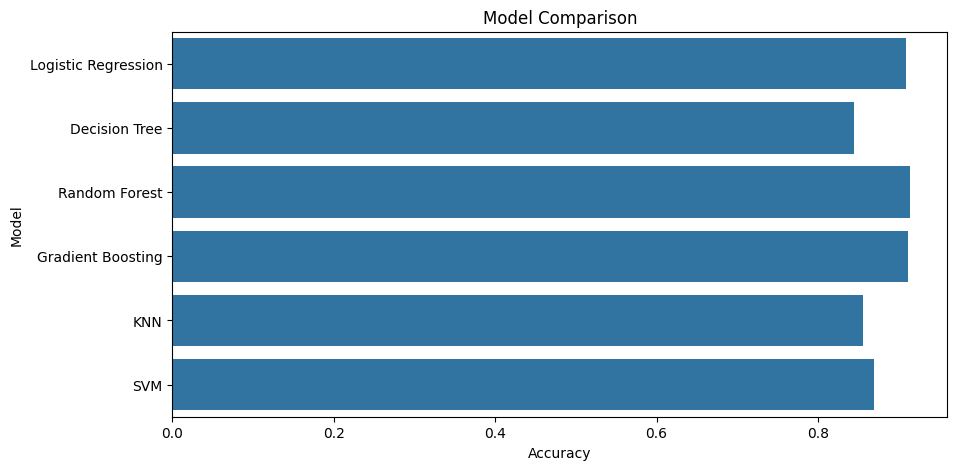

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results
)

plt.title("Model Comparison")
plt.show()

In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance


,Feature,Importance
5,HbA1c_Level,0.456337
2,BMI,0.152529
0,Age,0.150356
3,Systolic_BP,0.106297
4,Diastolic_BP,0.092294
1,Gender,0.016005
6,Source_Year_2015-2016,0.013364
7,Source_Year_2017-2018,0.012818


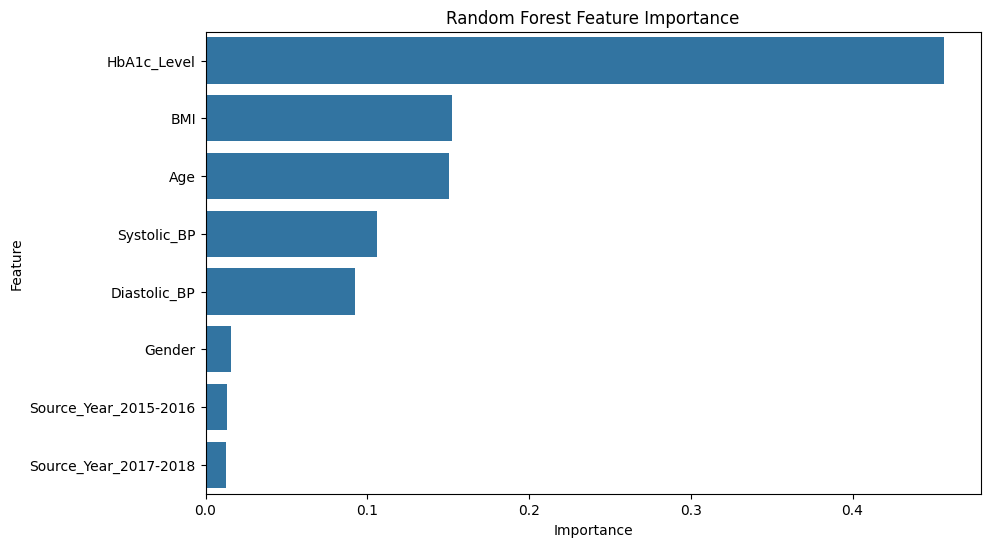

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")
plt.show()

In [50]:
import joblib

joblib.dump(rf, "diabetes_prediction_model.pkl")

['diabetes_prediction_model.pkl']

In [51]:
model = joblib.load("diabetes_prediction_model.pkl")